In [1]:
import pandas as pd
import numpy as np

# 先讀進模擬資料
# data = pd.read_csv(r"C:\Users\USER\Desktop\碩論\程式碼\embedding_data.csv")

data = pd.read_csv(r"C:\Users\USER\Desktop\碩論\程式碼\C\raw_data.csv")

cols = data.columns[:-1].to_list() 

whole = data.copy()

data = whole.iloc[0:700,:]

# data[cols] = (data[cols] - data[cols].mean()) / data[cols].std() # 針對變數標準化，後面做softmax的時候，數值才不會爆掉

validation = whole.iloc[700:1000,:]

# validation[cols] = (validation[cols] - validation[cols].mean()) / validation[cols].std()

# ### 先用傳統統計模型驗證
X = data[cols]

# XTX = X.T @ X

y = data["Y"]

In [ ]:
# pip install tqdm

Note: you may need to restart the kernel to use updated packages.


In [2]:
import torch
import torch.nn as nn
import numpy as np
import torch.nn.functional as F

def train_attention_model(X, y, epochs=1000, lr=0.001):

    if isinstance(X, pd.DataFrame): 
        X = torch.tensor(
            X.values,
            dtype=torch.float32
        )

    if isinstance(y, pd.Series):
        y = torch.tensor(
            y.values,
            dtype=torch.float32
        )

    N = X.shape[0]
    P = X.shape[1]

    y = y.reshape(-1, 1)

    X_Y_train = torch.cat(
        (X, y),
        dim=1
    )

    X_Y_features = X_Y_train.t()

    # dk = 32

    d_k = 32**2
    W_Q = nn.Linear(
        X_Y_features.shape[1],
        d_k,
        bias=False
    )

    W_K = nn.Linear(
        X_Y_features.shape[1],
        d_k,
        bias=False
    )


    optimizer = torch.optim.Adam(
        list(W_Q.parameters()) +
        list(W_K.parameters()), 

        lr=lr

    )


    lam = 1

    # Deep GLM 
    p = X.shape[1]

    I = torch.eye(
        p,
        dtype=X.dtype,
        device=X.device
    )


    for epoch in range(epochs):

        Q = W_Q(X_Y_features)
        
        K = W_K(X_Y_features)

        scores = torch.matmul(
            Q,
            K.transpose(-2,-1)
        ) 

        # scores = scores / np.sqrt(dk)

        attention_matrix = F.softmax(
            scores / (d_k ** 0.5),
            dim=-1
        )

        # 把Y再從矩陣中拿掉
        A = attention_matrix[:-1,:-1]

        # 矩陣乘上Y的變異數
        var_y = torch.var(y)

        # A_var_y = A * var_y


        # beta
        if torch.linalg.det(A)>0:
            beta = torch.linalg.solve(X.T @ X + I + A/torch.trace(A),X.T @ y)
        else:
            beta = torch.linalg.solve(X.T @ X + I - A/torch.trace(A),X.T @ y)


        y_hat = X@beta


        loss = F.mse_loss(
            y_hat,
            y
        )


        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    with torch.no_grad():

        Q = W_Q(X_Y_features)
        
        K = W_K(X_Y_features)

        scores = torch.matmul(
            Q,
            K.transpose(-2,-1)
        ) 

        # scores = scores / np.sqrt(dk)

        attention_matrix = F.softmax(
            scores / (d_k ** 0.5),
            dim=-1
        )

        # 把Y再從矩陣中拿掉
        A = attention_matrix[:-1,:-1]

        final_attn = A.clone()

        # 矩陣乘上Y的變異數
        var_y = torch.var(y)

        A_var_y = A * var_y

        # beta
        if torch.linalg.det(A)>0:
            final_beta = torch.linalg.solve(X.T @ X + I + A/torch.trace(A),X.T @ y)
        else: 
            final_beta = torch.linalg.solve(X.T @ X + I - A/torch.trace(A),X.T @ y)

        # adaptive
        if torch.linalg.det(A)>0:
            adaptive_matrix = I + A/torch.trace(A)
        else:
            adaptive_matrix = I - A/torch.trace(A)


    return (
        final_beta.detach(),
        final_attn.detach(),
        adaptive_matrix.detach()
    )

In [3]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from tqdm import tqdm

n_repeat = 100

beta_results = []
mse_results = []
rmse_results = []
r2_results = []
attention_results = []
adaptive_results = []

for seed in tqdm(range(n_repeat), desc="Simulation"):

    torch.manual_seed(seed)
    np.random.seed(seed)


    beta_attn, attn_matrix, adaptive_matrix = train_attention_model(
        X,
        y
    )


    beta_results.append(
        beta_attn.numpy()
    )

    attention_results.append(
        attn_matrix.numpy()
    )

    adaptive_results.append(
    adaptive_matrix.numpy()
    )


    # validation

    X_val = validation[cols].values

    y_pred = (
        torch.tensor(
            X_val,
            dtype=torch.float32
        )
        @ beta_attn
    ).numpy()

    y_val = validation["Y"].values

    mse = mean_squared_error(
        y_val,
        y_pred
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        y_val,
        y_pred
    )


    mse_results.append(mse)
    rmse_results.append(rmse)
    r2_results.append(r2)

Simulation: 100%|██████████| 100/100 [21:34<00:00, 12.95s/it]


In [4]:
beta_results = np.array(beta_results)

beta_mean = beta_results.mean(axis=0)

beta_sd = beta_results.std(axis=0)

In [5]:
# 用套件驗證OLS
import statsmodels.api as sm

X = data[cols]

model = sm.OLS(
    data["Y"],
    X          # 不加 constant
)

result = model.fit()

beta_ols = result.params.values

y_pred_ols = X_val @ beta_ols

mse_ols = mean_squared_error(
    y_val,
    y_pred_ols
)

rmse_ols = np.sqrt(mse_ols)

ols_r2 = r2_score(y_val, y_pred_ols)

In [6]:
# Ridge
from sklearn.linear_model import Ridge
# ======================
# Split X and Y
# ======================

X_train = data[cols].values
y_train = data["Y"].values

# ======================
# Ridge model
# ======================

ridge = Ridge(alpha=1.0, fit_intercept=False)

ridge.fit(
    X_train,
    y_train,
)

beta_ridge = ridge.coef_

y_pred_ridge = X_val @ beta_ridge

mse_ridge = mean_squared_error(
    y_val,
    y_pred_ridge
)

rmse_ridge = np.sqrt(mse_ridge)

ridge_r2 = r2_score(y_val, y_pred_ridge)

In [7]:
# 模擬資料生成時的實際係數
true_beta = pd.read_csv(
    r"C:\Users\USER\Desktop\碩論\程式碼\C\true_beta.csv"
)

beta_true = true_beta["True_Coefficient"].values
ols_bias = abs(beta_ols - beta_true)
attn_bias = abs(beta_mean.flatten() - beta_true) # 平均係數
ridge_bias = abs(beta_ridge - beta_true)

In [8]:
beta_summary = pd.DataFrame({

    "Beta_mean(DeepGLM)":beta_mean.flatten(),

    "Beta_SD(DeepGLM)":beta_sd.flatten(),

    "OLS":result.params,

    "Ridge":beta_ridge,

    "Simulation": beta_true

})


print(beta_summary)
print(f"OLS的係數偏差:{ols_bias.sum():.6f}")
print(f"Ridge的係數偏差:{ridge_bias.sum():.6f}")
print(f"DeepGLM的平均係數偏差:{attn_bias.sum():.6f}")

           Beta_mean(DeepGLM)  Beta_SD(DeepGLM)       OLS     Ridge  \
Intercept            1.929867          0.000484  1.932738  1.929794   
X1                   1.981837          0.000630  1.984513  1.981674   
X2                  -1.457627          0.000498 -1.459544 -1.457278   
X3                   0.522754          0.000181  0.522878  0.522690   
X4                  -0.132791          0.000123 -0.132968 -0.132743   
X5                   3.012729          0.000399  3.017042  3.012712   
X6                   0.004402          0.000083  0.004333  0.004400   
X7                  -0.049669          0.000125 -0.049727 -0.049651   
X8                  -0.059323          0.000101 -0.059095 -0.059340   
X9                  -0.039539          0.000146 -0.039714 -0.039510   
X10                  0.013365          0.000044  0.013323  0.013375   

           Simulation  
Intercept         1.0  
X1                2.0  
X2               -1.5  
X3                0.5  
X4                0.0  
X5 

In [9]:
metric_summary = pd.DataFrame({

    "Metric":[
        "MSE",
        "RMSE",
        "R2",
    ],

    "Mean(DeepGLM)":[
        np.mean(mse_results),
        np.mean(rmse_results),
        np.mean(r2_results)
    ],

    "SD(DeepGLM)":[
        np.std(mse_results),
        np.std(rmse_results),
        np.std(r2_results)
    ],

    "OLS":[
        mse_ols,
        rmse_ols,
        ols_r2
    ],

    "Ridge":[
        mse_ridge,
        rmse_ridge,
        ridge_r2
    ]

})


print(metric_summary)

  Metric  Mean(DeepGLM)  SD(DeepGLM)       OLS     Ridge
0    MSE       3.850187     0.000353  3.850518  3.850267
1   RMSE       1.962189     0.000090  1.962274  1.962210
2     R2       0.796719     0.000019  0.796702  0.796715


In [10]:
attention_results = np.array(attention_results)

attention_mean = attention_results.mean(axis=0)

attention_sd = attention_results.std(axis=0)

attention_summary = pd.DataFrame(
    index=cols,
    columns=cols
)

for i in range(len(cols)):
    for j in range(len(cols)):

        attention_summary.iloc[i,j] = (
            f"{attention_mean[i,j]:.4f}"
            " ± "
            f"{attention_sd[i,j]:.4f}"
        )

print(attention_summary)

                 Intercept               X1               X2               X3  \
Intercept  0.1500 ± 0.3571  0.0100 ± 0.0995  0.2400 ± 0.4271  0.0100 ± 0.0995   
X1         0.0599 ± 0.2372  0.0801 ± 0.2713  0.2700 ± 0.4440  0.0199 ± 0.1392   
X2         0.0000 ± 0.0000  0.0000 ± 0.0000  0.7300 ± 0.4440  0.0000 ± 0.0000   
X3         0.0020 ± 0.0142  0.0050 ± 0.0366  0.0102 ± 0.0995  0.6000 ± 0.4899   
X4         0.0000 ± 0.0002  0.0001 ± 0.0006  0.0422 ± 0.1782  0.0000 ± 0.0003   
X5         0.0200 ± 0.1400  0.0100 ± 0.0995  0.2300 ± 0.4208  0.0100 ± 0.0995   
X6         0.0001 ± 0.0010  0.0000 ± 0.0004  0.0244 ± 0.1431  0.0001 ± 0.0008   
X7         0.0005 ± 0.0049  0.0003 ± 0.0030  0.0310 ± 0.1482  0.0003 ± 0.0017   
X8         0.0053 ± 0.0352  0.0019 ± 0.0133  0.0117 ± 0.1004  0.0264 ± 0.1367   
X9         0.0000 ± 0.0000  0.0000 ± 0.0000  0.0374 ± 0.1563  0.0000 ± 0.0000   
X10        0.0008 ± 0.0072  0.0004 ± 0.0040  0.0046 ± 0.0294  0.0111 ± 0.0995   

                        X4 

In [11]:
adaptive_results = np.array(adaptive_results)

adaptive_mean = adaptive_results.mean(axis=0)

adaptive_sd = adaptive_results.std(axis=0)

adaptive_summary = pd.DataFrame(
    index=cols,
    columns=cols
)

for i in range(len(cols)):
    for j in range(len(cols)):
        adaptive_summary.iloc[i,j] = (
            f"{adaptive_mean[i,j]:.4f}"
            " ± "
            f"{adaptive_sd[i,j]:.4f}"
        )

print(adaptive_summary)

                  Intercept                X1                X2  \
Intercept   0.9797 ± 0.0849  -0.0033 ± 0.0332  -0.0353 ± 0.0893   
X1         -0.0318 ± 0.1407   0.9832 ± 0.1044  -0.0290 ± 0.0660   
X2         -0.0000 ± 0.0000  -0.0000 ± 0.0000   0.8355 ± 0.2351   
X3         -0.0020 ± 0.0141  -0.0032 ± 0.0198  -0.0016 ± 0.0142   
X4         -0.0000 ± 0.0001  -0.0000 ± 0.0003  -0.0143 ± 0.0573   
X5         -0.0121 ± 0.0860  -0.0020 ± 0.0199  -0.0291 ± 0.0597   
X6         -0.0001 ± 0.0007  -0.0000 ± 0.0003  -0.0062 ± 0.0357   
X7         -0.0004 ± 0.0035  -0.0002 ± 0.0021  -0.0119 ± 0.0559   
X8         -0.0019 ± 0.0118  -0.0017 ± 0.0132  -0.0039 ± 0.0335   
X9         -0.0000 ± 0.0000  -0.0000 ± 0.0000  -0.0158 ± 0.0730   
X10        -0.0006 ± 0.0052  -0.0003 ± 0.0029  -0.0027 ± 0.0197   

                         X3                X4                X5  \
Intercept  -0.0025 ± 0.0249  -0.0000 ± 0.0000  -0.0153 ± 0.0792   
X1         -0.0066 ± 0.0463   0.0000 ± 0.0004  -0.0158 ± 0.08

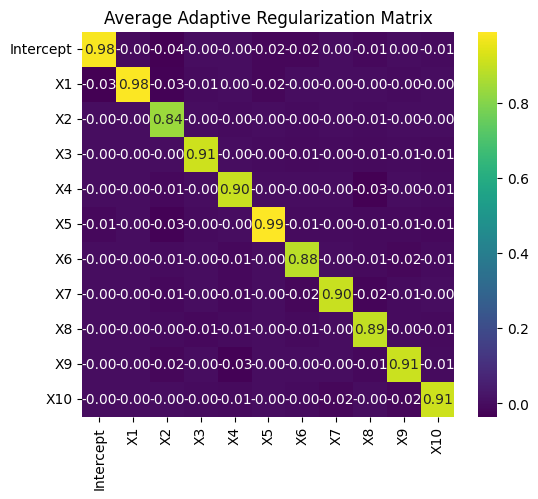

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.heatmap(
    adaptive_mean,
    xticklabels=cols,
    yticklabels=cols,
    annot=True,
    fmt=".2f",
    cmap="viridis"
)

plt.title("Average Adaptive Regularization Matrix")
plt.show()